In [33]:
import cmocean
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from pathlib import Path

import hfplot.figure.figure as hffig

import pycompo.core.utils as pcutil
import pycompo.core.filter as pcfilter
from pycompo.core.composite import get_rainbelt

warnings.filterwarnings(action='ignore')

# ------------------------------------------------------------------------------
# define functions
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    import matplotlib.colors as colors

    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# read in configuration file
ana_idf = "ngc5004_opv4_w0_test"
config_file = f"/home/m/m300738/libs/pycompo/config/settings_{ana_idf}.yaml"
config = pcutil.read_yaml_config(config_file)
analysis_times = pcutil.create_analysis_times(config)

# Unsmoothed rainbelts

In [34]:
# read in precipitation
inpath = Path(config['data']['inpaths']['pr'])
in_pattern = f"{config['exp']}_tropical_pr_*.nc"
infiles = sorted([str(f) for f in inpath.rglob(in_pattern)])
pr_clim = xr.open_mfdataset(infiles).squeeze()['pr']

# build climatology
if config['composite']['rainbelt_subsampling']['mode'] == 'roll_avg':
    pr_clim = pcutil.roll_avg(
        pr_clim, config['detrend']['clim_avg_days'], config['data']['spd'],
        )

else:
    raise ValueError(
        "Please provide a valid mode for 'rainbelt_subsampling'! " +
        "Valid modes are 'roll_avg_clim' and 'roll_avg'."
        )
pr_clim = pr_clim.sel(lat=slice(-15, 15))

# build rainbelt
rainbelt = get_rainbelt(analysis_times, config, quantile=0.8).compute()

### 90 days

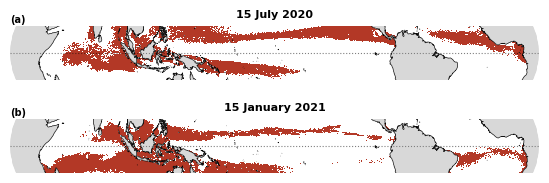

In [26]:
# MAP PLOT
# ------------------------------------------------------------------------------
cmap = truncate_colormap(cmocean.cm.amp, 0, 0.6)

fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    plot_data = np.ma.masked_equal(rainbelt.sel(time=time), 0)
    cf = axs[i, 0].pcolormesh(
        rainbelt['lon'], rainbelt['lat'], plot_data,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=1,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3, zorder=10)

    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()
plt.show()

### 60 days

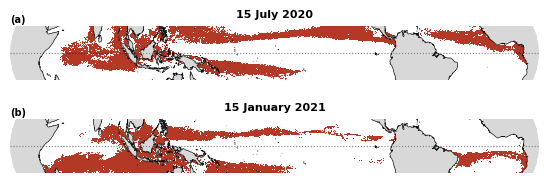

In [31]:
# MAP PLOT
# ------------------------------------------------------------------------------
cmap = truncate_colormap(cmocean.cm.amp, 0, 0.6)

fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    plot_data = np.ma.masked_equal(rainbelt.sel(time=time), 0)
    cf = axs[i, 0].pcolormesh(
        rainbelt['lon'], rainbelt['lat'], plot_data,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=1,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3, zorder=10)

    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()
plt.show()

### 30 days

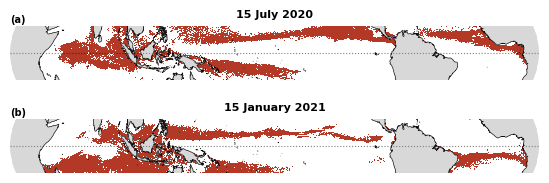

In [37]:
# MAP PLOT
# ------------------------------------------------------------------------------
cmap = truncate_colormap(cmocean.cm.amp, 0, 0.6)

fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    plot_data = np.ma.masked_equal(rainbelt.sel(time=time), 0)
    cf = axs[i, 0].pcolormesh(
        rainbelt['lon'], rainbelt['lat'], plot_data,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=1,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3, zorder=10)

    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()

# Save plot
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figureA3.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()

# Smoothed rainbelts

In [7]:
# read in and filter precipitation
inpath = Path(config['data']['inpaths']['pr'])
in_pattern = f"{config['exp']}_tropical_pr_*.nc"
infiles = sorted([str(f) for f in inpath.rglob(in_pattern)])
pr_clim = xr.open_mfdataset(infiles).squeeze()['pr']
pr_clim = pcfilter.get_gaussian_filter_bg_ano(pr_clim, **config['filter'])\
    ['pr_bg']

# build climatology
if config['composite']['rainbelt_subsampling']['mode'] == 'roll_avg':
    pr_clim = pcutil.roll_avg(
        pr_clim, config['detrend']['clim_avg_days'], config['data']['spd'],
        )

else:
    raise ValueError(
        "Please provide a valid mode for 'rainbelt_subsampling'! " +
        "Valid modes are 'roll_avg_clim' and 'roll_avg'."
        )
pr_clim = pr_clim.sel(lat=slice(-15, 15))

# build rainbelt
rainbelt = get_rainbelt(analysis_times, config, quantile=0.8).compute()

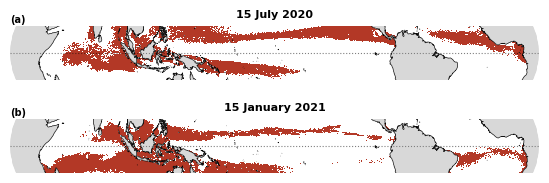

In [ ]:
# MAP PLOT
# ------------------------------------------------------------------------------
cmap = truncate_colormap(cmocean.cm.amp, 0, 0.6)

fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    plot_data = np.ma.masked_equal(rainbelt.sel(time=time), 0)
    cf = axs[i, 0].pcolormesh(
        rainbelt['lon'], rainbelt['lat'], plot_data,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=1,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3, zorder=10)

    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()
plt.show()

### Plotting

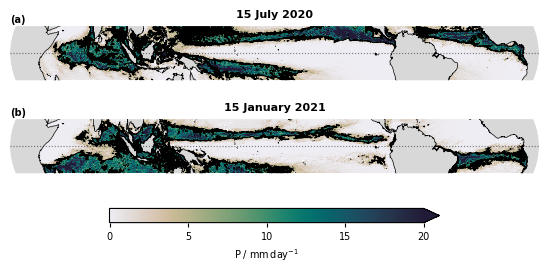

In [ ]:
fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

# MAP PLOT
# ------------------------------------------------------------------------------
for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    cf = axs[i, 0].pcolormesh(
        pr_clim['lon'], pr_clim['lat'], pr_clim.sel(time=time),
        cmap=cmocean.cm.rain, transform=ccrs.PlateCarree(), vmin=0, vmax=20
    )
    axs[i, 0].contour(
        rainbelt['lon'], rainbelt['lat'], rainbelt.sel(time=time),
        transform=ccrs.PlateCarree(), colors='k', linewidths=0.7,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3)
    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

cbar_ax = fig.add_axes([0.2, 0.37, 0.6, 0.015])
fig.colorbar(
    cf, cax=cbar_ax, orientation='horizontal',
    label='P / mm$\,$day$^{-1}$', extend='max', ticks=np.arange(0, 26, 5)
)

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figureA3.png')
plt.savefig(str(outpath/outfile), dpi=600)
plt.show()

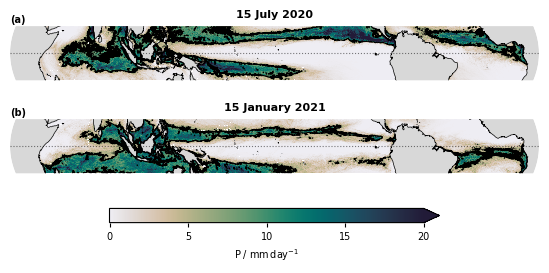

In [73]:
fig, axs = hffig.init_subfig(
    style=('ams', 'two_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False, offset_x=0, offset_y=2,
    proj=ccrs.Mollweide(central_longitude=-160),
    )

# MAP PLOT
# ------------------------------------------------------------------------------
for i, time in enumerate(
    [np.datetime64('2020-07-15'), np.datetime64('2021-01-15')],
    ):
    cf = axs[i, 0].pcolormesh(
        pr_clim['lon'], pr_clim['lat'], pr_clim.sel(time=time),
        cmap=cmocean.cm.rain, transform=ccrs.PlateCarree(), vmin=0, vmax=20
    )
    axs[i, 0].contour(
        rainbelt['lon'], rainbelt['lat'], rainbelt.sel(time=time),
        transform=ccrs.PlateCarree(), colors='k', linewidths=0.7,
    )

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3)
    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)
    lon_line = np.linspace(-180, 180, 361)
    axs[i, 0].plot(
        lon_line, np.full_like(lon_line, 0),
        transform=ccrs.PlateCarree(), linewidth=0.8, linestyle=':', alpha=0.5,
        color='k',
        )
    axs[i, 0].set_title(
        f"{time.astype('datetime64[D]').item().strftime('%d %B %Y')}", fontsize=8,
        )

cbar_ax = fig.add_axes([0.2, 0.37, 0.6, 0.015])
fig.colorbar(
    cf, cax=cbar_ax, orientation='horizontal',
    label='P / mm$\,$day$^{-1}$', extend='max', ticks=np.arange(0, 26, 5)
)

fig.subplots_adjust(hspace=-1.1)
plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figureA3.png')
plt.savefig(str(outpath/outfile), dpi=600)
plt.show()